# Infilling Accuracy Analysis

This notebook loads `best_checkpoint_accuracy_*.json` outputs from `outputs/analysis/checkpoint_loss_curves/` and plots:

- summary accuracy, throughput, and latency for each evaluated model variant
- diffusion-step tradeoffs relative to the AR baseline
- right-vs-wrong tactic and proof length statistics
- frequent tactics among exact-match successes and example-level slices

It handles both older summary-only JSON files and newer rich JSON files that include `correct_examples` and `length_stats_by_outcome`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates.extend(
        [
            Path("/groups/tensorlab/myang2/cs165-project"),
            Path("/resnick/groups/tensorlab/myang2/cs165-project"),
        ]
    )
    for candidate in candidates:
        if (candidate / "scripts" / "eval_infilling_accuracy.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from this notebook.")


REPO_ROOT = find_repo_root()
ANALYSIS_DIR = REPO_ROOT / "outputs" / "analysis" / "checkpoint_loss_curves"


def try_relative(path: Path) -> str:
    try:
        return str(path.resolve().relative_to(REPO_ROOT.resolve()))
    except ValueError:
        return str(path)


def model_variant_label(result: dict[str, Any]) -> str:
    family = str(result.get("model_family") or "unknown")
    if family == "diffusion":
        return f"diffusion-{result.get('steps', '?')} steps"
    if family == "ar":
        eval_variant = str(result.get("eval_variant") or "")
        if eval_variant == "base_model_no_lora":
            return "autoregressive-base"
        return "autoregressive"
    return family


def load_accuracy_payloads() -> list[dict[str, Any]]:
    payloads: list[dict[str, Any]] = []
    for path in sorted(ANALYSIS_DIR.glob("best_checkpoint_accuracy_*.json")):
        with path.open("r", encoding="utf-8") as handle:
            payload = json.load(handle)
        payloads.append(
            {
                "path": path,
                "file_name": path.name,
                "job_id": path.stem.split("_")[-1],
                "mtime": pd.Timestamp(path.stat().st_mtime, unit="s"),
                "payload": payload,
            }
        )
    if not payloads:
        raise FileNotFoundError(f"No accuracy JSON files found in {ANALYSIS_DIR}")
    return payloads


def flatten_results(payloads: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for entry in payloads:
        payload = entry["payload"]
        selected = payload.get("selected_checkpoints") or {}
        for result in payload.get("results", []):
            row = {
                "job_id": entry["job_id"],
                "file_name": entry["file_name"],
                "file_path": try_relative(entry["path"]),
                "mtime": entry["mtime"],
                "dataset_path": payload.get("dataset_path"),
                "num_examples_payload": payload.get("num_examples"),
                "model_family": result.get("model_family"),
                "model_variant": model_variant_label(result),
                "steps": result.get("steps"),
                "source_checkpoint_name": result.get("source_checkpoint_name"),
                "source_global_step": result.get("source_global_step"),
                "source_eval_loss": result.get("source_eval_loss"),
                "exact_match_accuracy": result.get("exact_match_accuracy"),
                "exact_match_accuracy_pct": 100.0 * float(result.get("exact_match_accuracy") or 0.0),
                "exact_match_accuracy_on_valid": result.get("exact_match_accuracy_on_valid"),
                "examples_per_second": result.get("examples_per_second"),
                "generation_seconds": result.get("generation_seconds"),
                "latency_ms_mean": 1000.0 * float(result.get("latency_seconds_mean_effective") or 0.0),
                "latency_ms_p50": 1000.0 * float(result.get("latency_seconds_p50_effective") or 0.0),
                "latency_ms_p95": 1000.0 * float(result.get("latency_seconds_p95_effective") or 0.0),
                "nonempty_prediction_rate": result.get("nonempty_prediction_rate"),
                "num_exact_matches": result.get("num_exact_matches"),
                "num_valid_examples": result.get("num_valid_examples"),
                "num_invalid_examples": result.get("num_invalid_examples"),
                "num_correct_examples_saved": result.get("num_correct_examples_saved", 0),
                "has_correct_examples": "correct_examples" in result,
                "has_length_stats": "length_stats_by_outcome" in result,
                "selected_checkpoint_path": (selected.get(str(result.get("model_family") or "")) or {}).get("checkpoint_path"),
            }
            rows.append(row)
    return pd.DataFrame(rows)


def flatten_length_stats(payloads: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for entry in payloads:
        for result in entry["payload"].get("results", []):
            stats_by_outcome = result.get("length_stats_by_outcome") or {}
            for outcome, outcome_stats in stats_by_outcome.items():
                if not isinstance(outcome_stats, dict):
                    continue
                for measure_name, measure_stats in outcome_stats.items():
                    if measure_name in {"count", "fraction"}:
                        continue
                    if not isinstance(measure_stats, dict):
                        continue
                    for unit, unit_stats in measure_stats.items():
                        if not isinstance(unit_stats, dict):
                            continue
                        rows.append(
                            {
                                "job_id": entry["job_id"],
                                "file_name": entry["file_name"],
                                "mtime": entry["mtime"],
                                "model_family": result.get("model_family"),
                                "model_variant": model_variant_label(result),
                                "steps": result.get("steps"),
                                "outcome": outcome,
                                "measure": measure_name,
                                "unit": unit,
                                "count": unit_stats.get("count"),
                                "mean": unit_stats.get("mean"),
                                "p50": unit_stats.get("p50"),
                                "p95": unit_stats.get("p95"),
                                "min": unit_stats.get("min"),
                                "max": unit_stats.get("max"),
                            }
                        )
    return pd.DataFrame(rows)


def flatten_correct_examples(payloads: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for entry in payloads:
        for result in entry["payload"].get("results", []):
            for example in result.get("correct_examples", []):
                target_tactic = str(example.get("target_tactic") or "")
                predicted_tactic = str(example.get("predicted_tactic") or "")
                proof_with_hole = str(example.get("proof_with_hole") or "")
                theorem_statement = str(example.get("theorem_statement") or "")
                rows.append(
                    {
                        "job_id": entry["job_id"],
                        "file_name": entry["file_name"],
                        "mtime": entry["mtime"],
                        "model_family": result.get("model_family"),
                        "model_variant": model_variant_label(result),
                        "steps": result.get("steps"),
                        "example_index": example.get("example_index"),
                        "full_name": example.get("full_name"),
                        "theorem_statement": theorem_statement,
                        "proof_with_hole": proof_with_hole,
                        "target_tactic": target_tactic,
                        "predicted_tactic": predicted_tactic,
                        "target_tactic_chars": len(target_tactic),
                        "predicted_tactic_chars": len(predicted_tactic),
                        "proof_with_hole_chars": len(proof_with_hole),
                        "theorem_statement_chars": len(theorem_statement),
                    }
                )
    return pd.DataFrame(rows)


payloads = load_accuracy_payloads()
results_df = flatten_results(payloads)
length_stats_df = flatten_length_stats(payloads)
correct_examples_df = flatten_correct_examples(payloads)

latest_job_id = results_df.sort_values("mtime")["job_id"].iloc[-1]
detailed_job_ids = results_df.loc[
    results_df["has_correct_examples"] | results_df["has_length_stats"], "job_id"
].drop_duplicates()
selected_job_id = detailed_job_ids.iloc[-1] if not detailed_job_ids.empty else latest_job_id
selected_job_id = "61857699"

print(f"Repo root: {REPO_ROOT}")
print(f"Analysis dir: {ANALYSIS_DIR}")
print(f"Loaded {len(payloads)} accuracy JSON files")
print(f"Loaded {len(results_df)} result rows")
print(f"Loaded {len(correct_examples_df)} saved correct examples")
print(f"Selected job id for detailed plots: {selected_job_id}")

Repo root: /resnick/groups/tensorlab/myang2/cs165-project
Analysis dir: /resnick/groups/tensorlab/myang2/cs165-project/outputs/analysis/checkpoint_loss_curves
Loaded 7 accuracy JSON files
Loaded 38 result rows
Loaded 9874 saved correct examples
Selected job id for detailed plots: 61857699


In [2]:
overview_columns = [
    "job_id",
    "mtime",
    "model_variant",
    "source_checkpoint_name",
    "source_eval_loss",
    "exact_match_accuracy_pct",
    "examples_per_second",
    "latency_ms_p50",
    "num_exact_matches",
    "num_correct_examples_saved",
    "has_length_stats",
]

overview_df = results_df.sort_values(["mtime", "model_family", "steps"], ascending=[False, True, True])
display(overview_df[overview_columns].reset_index(drop=True))

selected_results_df = (
    results_df.loc[results_df["job_id"] == selected_job_id]
    .copy()
    .sort_values(["model_family", "steps"], na_position="last")
)
selected_length_stats_df = length_stats_df.loc[length_stats_df["job_id"] == selected_job_id].copy()
selected_correct_examples_df = correct_examples_df.loc[
    correct_examples_df["job_id"] == selected_job_id
].copy()

print("Selected job rows")
display(
    selected_results_df[
        [
            "model_variant",
            "source_checkpoint_name",
            "source_eval_loss",
            "exact_match_accuracy_pct",
            "examples_per_second",
            "latency_ms_mean",
            "latency_ms_p50",
            "latency_ms_p95",
            "num_exact_matches",
            "num_correct_examples_saved",
        ]
    ].reset_index(drop=True)
)

if not selected_correct_examples_df.empty:
    print("Top solved-example counts by model variant")
    display(
        selected_correct_examples_df.groupby("model_variant")
        .size()
        .rename("num_correct_examples")
        .sort_values(ascending=False)
        .to_frame()
    )
else:
    print("The selected job does not include saved correct examples.")

,job_id,mtime,model_variant,source_checkpoint_name,source_eval_loss,exact_match_accuracy_pct,examples_per_second,latency_ms_p50,num_exact_matches,num_correct_examples_saved,has_length_stats
0,61857696,2026-03-21 14:20:25.474146366,autoregressive,checkpoint-6250,1.334245,8.75,6.955601,123.012006,875,875,True
1,61857696,2026-03-21 14:20:25.474146366,autoregressive-base,checkpoint-6250,1.334245,0.06,3.835672,283.304138,6,6,True
2,61857696,2026-03-21 14:20:25.474146366,diffusion-1 steps,checkpoint-37500,0.388772,6.71,44.484621,21.307582,671,671,True
3,61857696,2026-03-21 14:20:25.474146366,diffusion-4 steps,checkpoint-37500,0.388772,7.63,11.334846,83.501032,763,763,True
4,61857696,2026-03-21 14:20:25.474146366,diffusion-16 steps,checkpoint-37500,0.388772,8.53,2.846554,332.683143,853,853,True
5,61857696,2026-03-21 14:20:25.474146366,diffusion-64 steps,checkpoint-37500,0.388772,7.99,0.713013,1328.107357,799,799,True
6,61857699,2026-03-21 11:03:10.783261061,autoregressive,checkpoint-6250,1.334245,6.38,7.160849,122.064470,319,319,True
7,61857699,2026-03-21 11:03:10.783261061,autoregressive-base,checkpoint-6250,1.334245,0.04,3.748321,281.117593,2,2,True
8,61857699,2026-03-21 11:03:10.783261061,diffusion-1 steps,checkpoint-37500,0.388772,4.80,46.740560,21.011836,240,240,True
9,61857699,2026-03-21 11:03:10.783261061,diffusion-4 steps,checkpoint-37500,0.388772,5.20,11.898533,83.056341,260,260,True


Selected job rows


,model_variant,source_checkpoint_name,source_eval_loss,exact_match_accuracy_pct,examples_per_second,latency_ms_mean,latency_ms_p50,latency_ms_p95,num_exact_matches,num_correct_examples_saved
0,autoregressive,checkpoint-6250,1.334245,6.38,7.160849,139.648237,122.064470,424.380975,319,319
1,autoregressive-base,checkpoint-6250,1.334245,0.04,3.748321,266.786143,281.117593,294.810527,2,2
2,diffusion-1 steps,checkpoint-37500,0.388772,4.80,46.740560,21.394694,21.011836,31.545033,240,240
3,diffusion-4 steps,checkpoint-37500,0.388772,5.20,11.898533,84.043972,83.056341,124.797550,260,260
4,diffusion-16 steps,checkpoint-37500,0.388772,5.88,2.991033,334.332662,329.452548,492.430315,294,294
5,diffusion-64 steps,checkpoint-37500,0.388772,5.04,0.748994,1335.124153,1316.171788,1982.179180,252,252


Top solved-example counts by model variant


,num_correct_examples
model_variant,
autoregressive,319
diffusion-16 steps,294
diffusion-4 steps,260
diffusion-64 steps,252
diffusion-1 steps,240
autoregressive-base,2


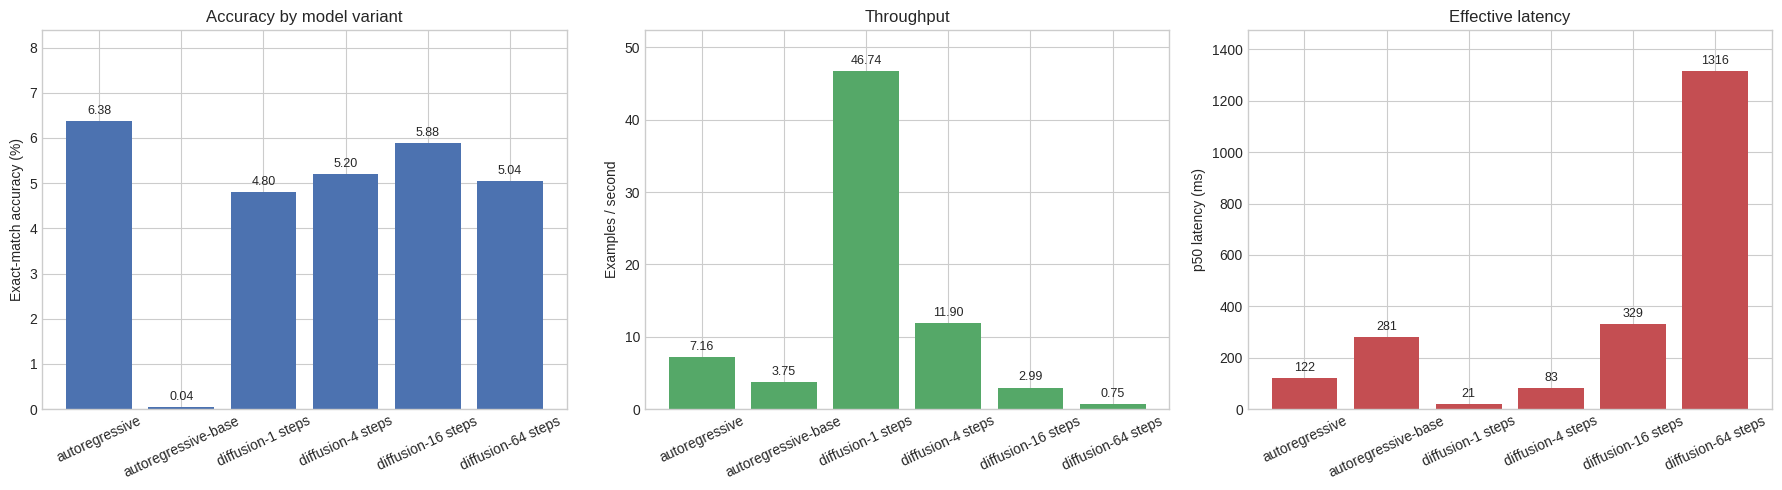

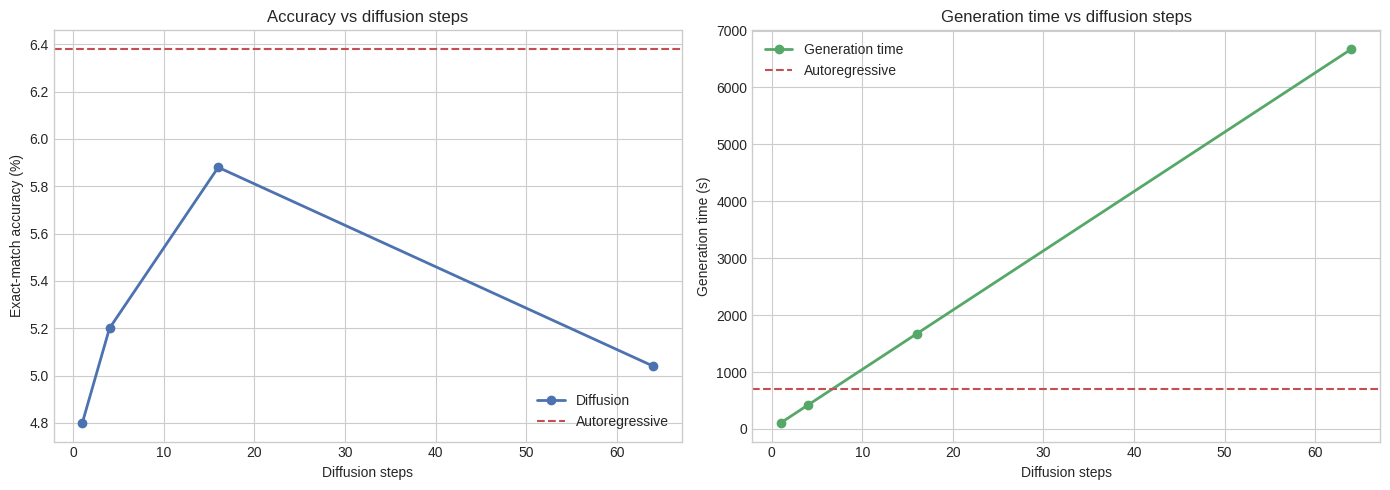

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = selected_results_df.copy()
labels = plot_df["model_variant"]

summary_specs = [
    ("exact_match_accuracy_pct", "#4C72B0", "Accuracy by model variant", "Exact-match accuracy (%)", "{:.2f}"),
    ("examples_per_second", "#55A868", "Throughput", "Examples / second", "{:.2f}"),
    ("latency_ms_p50", "#C44E52", "Effective latency", "p50 latency (ms)", "{:.0f}"),
]

for axis, (column, color, title, ylabel, label_format) in zip(axes, summary_specs):
    bars = axis.bar(labels, plot_df[column], color=color)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=25)
    ymax = max((bar.get_height() for bar in bars), default=0.0)
    label_offset = max(0.5, ymax * 0.03)
    axis.set_ylim(0, ymax + label_offset * 4.0)
    for bar in bars:
        height = bar.get_height()
        axis.annotate(
            label_format.format(height),
            (bar.get_x() + bar.get_width() / 2.0, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

diffusion_df = selected_results_df.loc[selected_results_df["model_family"] == "diffusion"].copy()
ar_df = selected_results_df.loc[selected_results_df["model_family"] == "ar"].copy()

if not diffusion_df.empty:
    diffusion_df = diffusion_df.sort_values("steps")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        diffusion_df["steps"],
        diffusion_df["exact_match_accuracy_pct"],
        marker="o",
        linewidth=2,
        color="#4C72B0",
        label="Diffusion",
    )
    if not ar_df.empty:
        axes[0].axhline(
            ar_df["exact_match_accuracy_pct"].iloc[0],
            linestyle="--",
            color="#C44E52",
            label="Autoregressive",
        )
    axes[0].set_title("Accuracy vs diffusion steps")
    axes[0].set_xlabel("Diffusion steps")
    axes[0].set_ylabel("Exact-match accuracy (%)")
    axes[0].legend()

    axes[1].plot(
        diffusion_df["steps"],
        diffusion_df["generation_seconds"],
        marker="o",
        linewidth=2,
        color="#55A868",
        label="Generation time",
    )
    if not ar_df.empty:
        axes[1].axhline(
            ar_df["generation_seconds"].iloc[0],
            linestyle="--",
            color="#C44E52",
            label="Autoregressive",
        )
    axes[1].set_title("Generation time vs diffusion steps")
    axes[1].set_xlabel("Diffusion steps")
    axes[1].set_ylabel("Generation time (s)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

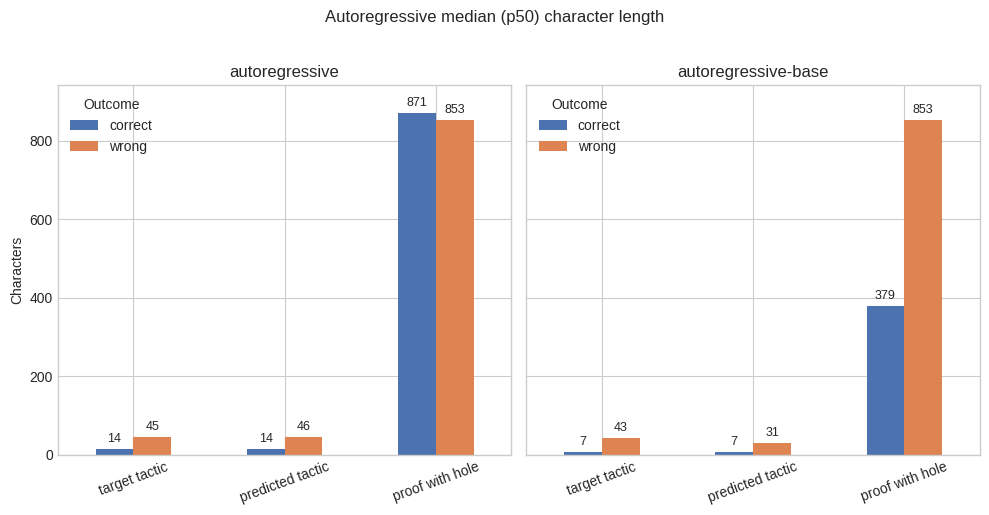

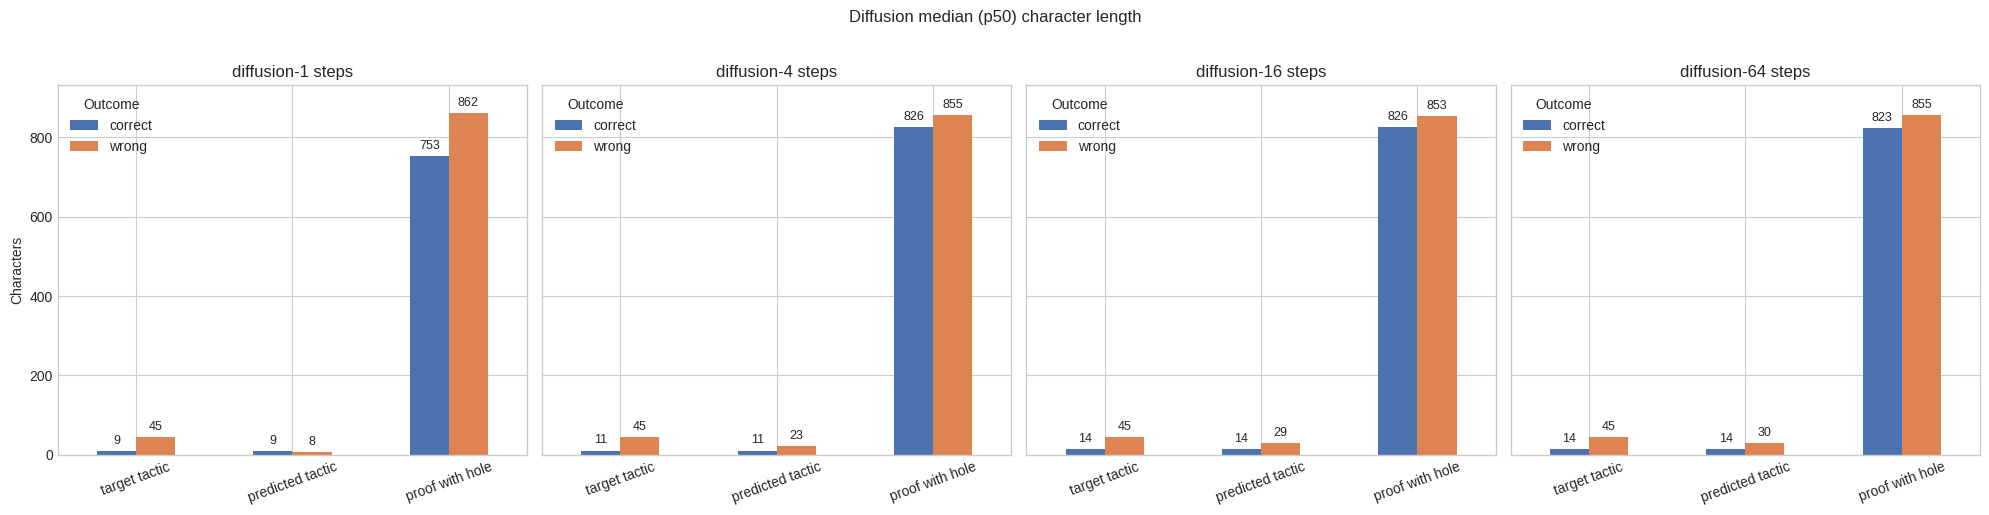

mean                 p50         \
outcome_label                            correct       wrong correct  wrong   
model_variant       measure_label                                             
autoregressive      predicted tactic   19.805643   50.082461    14.0   46.0   
                    proof with hole   942.670846  933.029695   871.0  853.0   
                    target tactic      19.805643   47.084811    14.0   45.0   
autoregressive-base predicted tactic    7.000000   70.974990     7.0   31.0   
                    proof with hole   379.000000  933.866747   379.0  853.0   
                    target tactic       7.000000   45.359744     7.0   43.0   
diffusion-1 steps   predicted tactic    9.333333    9.649370     9.0    8.0   
                    proof with hole   883.241667  936.186134   753.0  862.0   
                    target tactic       9.333333   47.160084     9.0   45.0   
diffusion-16 steps  predicted tactic   19.207483   31.564173    14.0   29.0   
                    proof with hole   900.792517  935.697195   826.0  853.0   
                    target tactic      19.207483   46.977263    14.0   45.0   
diffusion-4 steps   predicted tactic   15.030769   26.550422    11.0   23.0   
                    proof with hole   907.419231  935.083333   826.0  855.0   
                    target tactic      15.030769   47.007173    11.0   45.0   
diffusion-64 steps  predicted tactic   17.253968   34.646167    14.0   30.0   
                    proof with hole   902.289683  935.308972   823.0  855.0   
                    target tactic      17.230159   46.836563    14.0   45.0   

                                         p95           
outcome_label                        correct    wrong  
model_variant       measure_label                      
autoregressive      predicted tactic    61.0    95.00  
                    proof with hole   1522.9  1537.00  
                    target tactic       61.0    88.00  
autoregressive-base predicted tactic     7.0   411.15  
                    proof with hole    379.0  1537.00  
                    target tactic        7.0    88.00  
diffusion-1 steps   predicted tactic    17.0    23.00  
                    proof with hole   1935.0  1525.00  
                    target tactic       17.0    88.00  
diffusion-16 steps  predicted tactic    60.0    68.00  
                    proof with hole   1476.0  1566.00  
                    target tactic       60.0    88.00  
diffusion-4 steps   predicted tactic    42.0    60.00  
                    proof with hole   1505.8  1548.00  
                    target tactic       42.0    88.00  
diffusion-64 steps  predicted tactic    47.0    75.00  
                    proof with hole   1482.0  1559.70  
                    target tactic       47.0    88.00

,correct count,wrong count
model_variant,,
autoregressive,319.0,4681.0
autoregressive-base,2.0,4998.0
diffusion-1 steps,240.0,4760.0
diffusion-16 steps,294.0,4706.0
diffusion-4 steps,260.0,4740.0
diffusion-64 steps,252.0,4748.0


In [4]:
if selected_length_stats_df.empty:
    print("No detailed length statistics are available for the selected job.")
else:
    plot_length_df = selected_length_stats_df.loc[
        selected_length_stats_df["outcome"].isin(["correct_examples", "wrong_examples"])
        & selected_length_stats_df["measure"].isin(
            [
                "target_tactic_length",
                "predicted_tactic_length",
                "proof_with_hole_length",
            ]
        )
        & (selected_length_stats_df["unit"] == "chars")
    ].copy()

    pretty_measure = {
        "target_tactic_length": "target tactic",
        "predicted_tactic_length": "predicted tactic",
        "proof_with_hole_length": "proof with hole",
    }
    pretty_outcome = {
        "correct_examples": "correct",
        "wrong_examples": "wrong",
    }
    family_labels = {
        "ar": "Autoregressive",
        "diffusion": "Diffusion",
    }
    measure_order = ["target tactic", "predicted tactic", "proof with hole"]

    plot_length_df["measure_label"] = plot_length_df["measure"].map(pretty_measure)
    plot_length_df["outcome_label"] = plot_length_df["outcome"].map(pretty_outcome)

    for family, family_label in family_labels.items():
        family_results_df = selected_results_df.loc[
            selected_results_df["model_family"] == family
        ].copy()
        family_plot_df = plot_length_df.loc[plot_length_df["model_family"] == family].copy()
        if family_results_df.empty or family_plot_df.empty:
            continue

        variant_order = family_results_df.sort_values("steps", na_position="last")["model_variant"].tolist()
        fig_width = max(6, 5 * len(variant_order))
        fig, axes = plt.subplots(1, len(variant_order), figsize=(fig_width, 5), squeeze=False, sharey=True)
        axes = axes.ravel()

        family_max = 0.0
        variant_pivots = {}
        for variant in variant_order:
            variant_df = family_plot_df.loc[family_plot_df["model_variant"] == variant]
            pivot = variant_df.pivot_table(
                index="measure_label",
                columns="outcome_label",
                values="p50",
                aggfunc="first",
            ).reindex(measure_order)
            variant_pivots[variant] = pivot
            if not pivot.empty:
                family_max = max(family_max, float(pivot.max().max()))

        label_offset = max(8.0, family_max * 0.02)
        for axis, variant in zip(axes, variant_order):
            pivot = variant_pivots[variant]
            pivot.plot(kind="bar", ax=axis, color=["#4C72B0", "#DD8452"])
            axis.set_title(variant)
            axis.set_xlabel("")
            axis.set_ylabel("Characters")
            axis.tick_params(axis="x", rotation=20)
            axis.legend(title="Outcome")
            axis.set_ylim(0, family_max + label_offset * 4.0)
            for patch in axis.patches:
                height = patch.get_height()
                if pd.isna(height):
                    continue
                axis.annotate(
                    f"{height:.0f}",
                    (patch.get_x() + patch.get_width() / 2.0, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        fig.suptitle(f"{family_label} median (p50) character length", y=1.02)
        plt.tight_layout()
        plt.show()

    comparison_table = plot_length_df.pivot_table(
        index=["model_variant", "measure_label"],
        columns="outcome_label",
        values=["mean", "p50", "p95"],
        aggfunc="first",
    ).sort_index()
    display(comparison_table)

    if {"correct_examples", "wrong_examples"}.issubset(set(selected_length_stats_df["outcome"])):
        fraction_df = (
            selected_length_stats_df.loc[
                (selected_length_stats_df["measure"] == "target_tactic_length")
                & (selected_length_stats_df["unit"] == "chars")
                & selected_length_stats_df["outcome"].isin(["correct_examples", "wrong_examples"])
            ]
            [["model_variant", "outcome", "count"]]
            .drop_duplicates()
            .pivot(index="model_variant", columns="outcome", values="count")
            .fillna(0.0)
        )
        fraction_df.columns = [col.replace("_examples", "") for col in fraction_df.columns]
        display(fraction_df.rename(columns={"correct": "correct count", "wrong": "wrong count"}))

,model_family,model_variant,target_tactic,count
7,ar,autoregressive,constructor,29
40,ar,autoregressive,refine,22
25,ar,autoregressive,induction n with,20
41,ar,autoregressive,ring,19
20,ar,autoregressive,have hndeg : p.natDegree = 0 :=,17
51,ar,autoregressive,| zero => simp,16
39,ar,autoregressive,rcases le_total x y with (xy | yx),12
15,ar,autoregressive,filter_upwards [this] with y hy,11
9,ar,autoregressive,"exact diff_mem_nhdsWithin_diff (Icc_mem_nhdsWithin_Ici ⟨hc.1, hlt⟩) _",10
43,ar,autoregressive,rw [← Ici_diff_left],10


/tmp/ipykernel_601435/4241627039.py:75: UserWarning: Glyph 10216 (\N{MATHEMATICAL LEFT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_601435/4241627039.py:75: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/groups/tensorlab/myang2/cs165-project/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10216 (\N{MATHEMATICAL LEFT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/groups/tensorlab/myang2/cs165-project/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


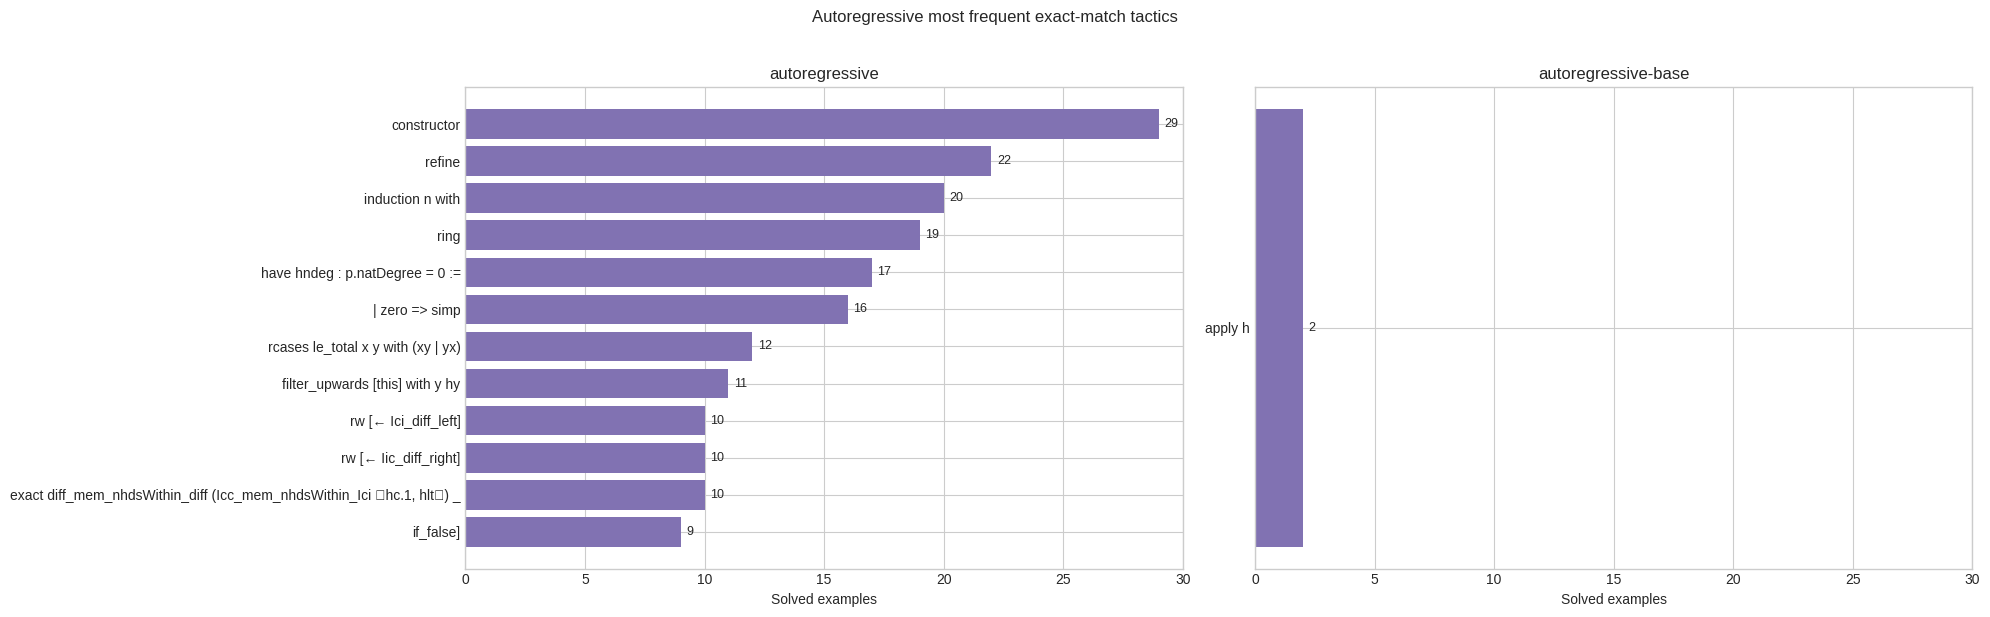

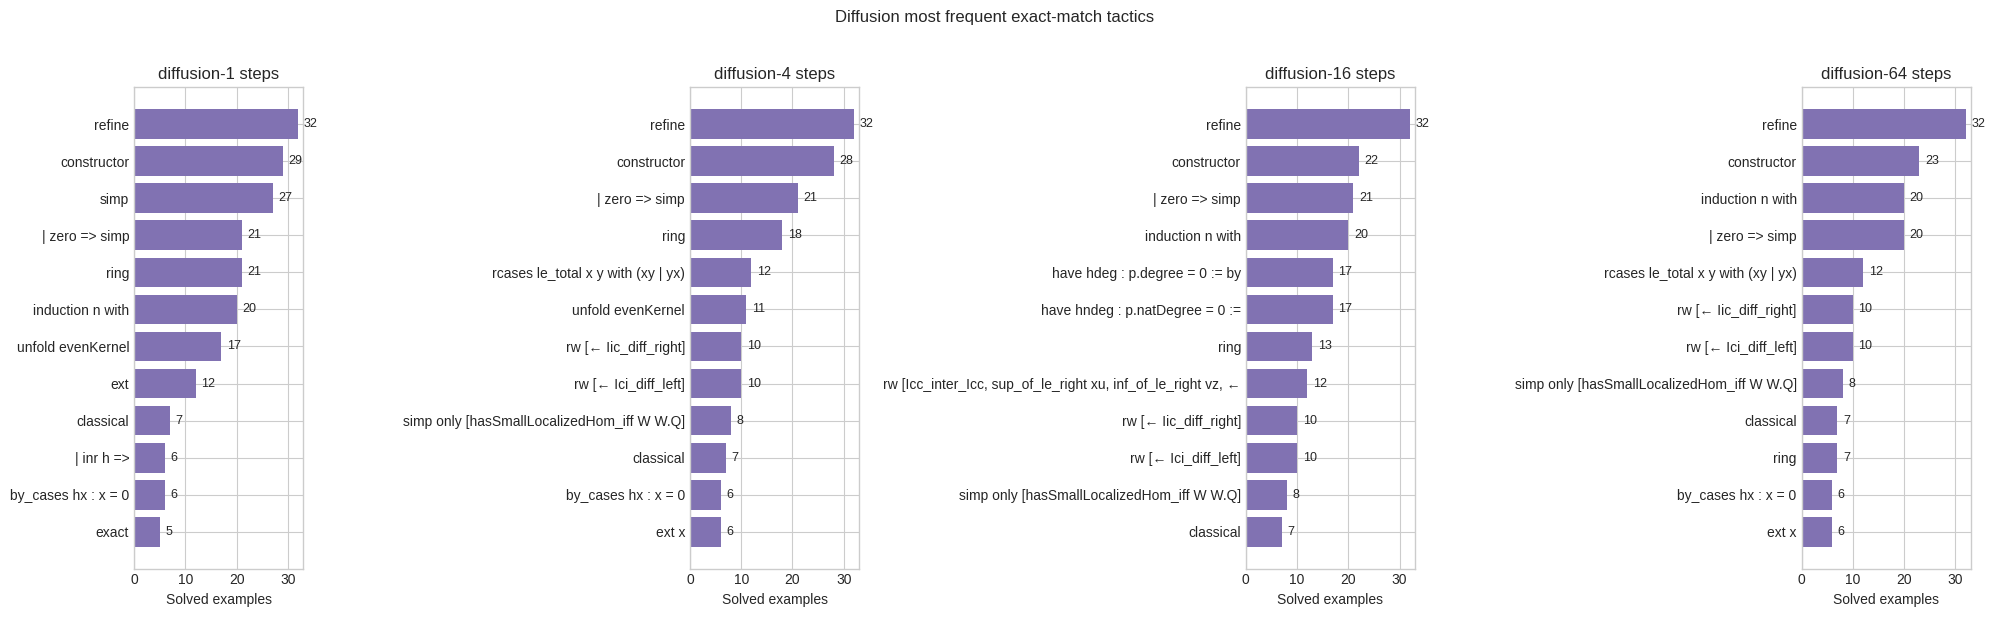

Examples solved by multiple model variants


,example_index,full_name,solved_by_variants,variants,target_tactic,proof_with_hole_chars
35,482,theorem_16832,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",simp,1704
38,491,theorem_16832,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",simp,1704
155,1457,theorem_16832,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",simp,1704
10,223,theorem_40450,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",classical,1099
118,1184,theorem_40450,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",classical,1099
146,1418,theorem_40450,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",classical,1099
227,2249,theorem_40450,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",classical,1099
231,2284,theorem_40450,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",classical,1099
300,2904,theorem_40450,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",classical,1099
302,2925,theorem_40450,5,"autoregressive, diffusion-1 steps, diffusion-16 steps, diffusion-4 steps, diffusion-64 steps",classical,1099


Sample of saved correct examples


,model_variant,example_index,full_name,target_tactic,predicted_tactic,proof_with_hole_chars,theorem_statement
0,autoregressive,481,theorem_16832,ext,ext,1705,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
1,autoregressive,490,theorem_16832,ext,ext,1705,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
2,autoregressive,1456,theorem_16832,ext,ext,1705,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
3,autoregressive,482,theorem_16832,simp,simp,1704,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
4,autoregressive,491,theorem_16832,simp,simp,1704,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
5,autoregressive,1457,theorem_16832,simp,simp,1704,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
6,autoregressive,480,theorem_16832,(differentiable_id.const_sub _).differentiableAt,(differentiable_id.const_sub _).differentiableAt,1660,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
7,autoregressive,489,theorem_16832,(differentiable_id.const_sub _).differentiableAt,(differentiable_id.const_sub _).differentiableAt,1660,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
8,autoregressive,1455,theorem_16832,(differentiable_id.const_sub _).differentiableAt,(differentiable_id.const_sub _).differentiableAt,1660,{a b : 𝕜} : DifferentiableAt 𝕜 (fun x ↦ f (b - x)) a ↔ DifferentiableAt 𝕜 f (b - a)
9,autoregressive,617,theorem_36067,ext i,ext i,1639,(f : M₁ →ₗ[R] M₂) (x : M₁) : LinearMap.toMatrix v₁ v₂ f *ᵥ v₁.repr x = v₂.repr (f x)


In [ ]:
if selected_correct_examples_df.empty:
    print("No saved correct examples are available for the selected job.")
else:
    top_tactics_df = (
        selected_correct_examples_df.groupby(["model_family", "model_variant", "target_tactic"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(
            ["model_family", "count", "model_variant", "target_tactic"],
            ascending=[True, False, True, True],
        )
    )
    display(top_tactics_df.head(25))

    family_labels = {
        "ar": "Autoregressive",
        "diffusion": "Diffusion",
    }

    for family, family_label in family_labels.items():
        family_examples_df = selected_correct_examples_df.loc[
            selected_correct_examples_df["model_family"] == family
        ].copy()
        if family_examples_df.empty:
            continue

        family_results_df = selected_results_df.loc[
            selected_results_df["model_family"] == family
        ].copy()
        variant_order = family_results_df.sort_values("steps", na_position="last")["model_variant"].tolist()
        top_tactics_by_variant = {}
        family_max = 0
        for variant in variant_order:
            top_variant = (
                family_examples_df.loc[family_examples_df["model_variant"] == variant]
                .groupby("target_tactic")
                .size()
                .rename("count")
                .sort_values(ascending=False)
                .head(12)
                .sort_values(ascending=True)
            )
            top_tactics_by_variant[variant] = top_variant
            if not top_variant.empty:
                family_max = max(family_max, int(top_variant.max()))

        fig_width = max(6, 5 * len(variant_order))
        fig, axes = plt.subplots(1, len(variant_order), figsize=(fig_width, 6), squeeze=False, sharex=True)
        axes = axes.ravel()
        for axis, variant in zip(axes, variant_order):
            top_variant = top_tactics_by_variant[variant]
            if top_variant.empty:
                axis.text(0.5, 0.5, "No saved exact matches", ha="center", va="center")
                axis.set_axis_off()
                continue

            bars = axis.barh(top_variant.index, top_variant.values, color="#8172B2")
            axis.set_title(variant)
            axis.set_xlabel("Solved examples")
            axis.set_xlim(0, family_max + 1)
            for bar in bars:
                width = bar.get_width()
                axis.annotate(
                    f"{int(width)}",
                    (width, bar.get_y() + bar.get_height() / 2.0),
                    xytext=(4, 0),
                    textcoords="offset points",
                    ha="left",
                    va="center",
                    fontsize=9,
                )

        fig.suptitle(f"{family_label} most frequent exact-match tactics", y=1.02)
        plt.tight_layout()
        plt.show()

    shared_examples_df = (
        selected_correct_examples_df.groupby(["example_index", "full_name"])
        .agg(
            solved_by_variants=("model_variant", "nunique"),
            variants=("model_variant", lambda values: ", ".join(sorted(set(values)))),
            target_tactic=("target_tactic", "first"),
            proof_with_hole_chars=("proof_with_hole_chars", "first"),
        )
        .reset_index()
        .sort_values(["solved_by_variants", "proof_with_hole_chars"], ascending=[False, False])
    )
    print("Examples solved by multiple model variants")
    display(shared_examples_df.head(20))

    print("Sample of saved correct examples")
    display(
        selected_correct_examples_df[
            [
                "model_variant",
                "example_index",
                "full_name",
                "target_tactic",
                "predicted_tactic",
                "proof_with_hole_chars",
                "theorem_statement",
            ]
        ]
        .sort_values(["model_variant", "proof_with_hole_chars"], ascending=[True, False])
        .head(30)
        .reset_index(drop=True)
    )